# Drew Schaffner Notebook
# P3: Text Exploration - Customer Support Language

- Author: [Drew Schaffner](https://github.com/dsmorgancodes/)
- Repository: [nlp-03-text-exploration](https://github.com/dsmomrgancodes/nlp-03-text-exploration/)
- Date: 2026-03

## Purpose
Apply tokenization, category frequency analysis, context windows, and bigrams to realistic customer support tickets.

## Analytical Questions
- What tokens dominate each support category?
- How does language differ across billing, technical, account, and shipping issues?
- Which words appear in similar contexts for routing and triage?
- What insights emerge before any machine learning model is used?

In [1]:
from collections import defaultdict
import logging
from pathlib import Path
import time

from datafun_toolkit.logger import get_logger, log_header, log_path
import matplotlib.pyplot as plt
import polars as pl

print("Imports complete.")

Imports complete.


In [2]:
LOG: logging.Logger = get_logger("CI", level="DEBUG")

NOTEBOOKS_PATH: Path = Path.cwd()
ROOT_PATH: Path = NOTEBOOKS_PATH.parent
SCRIPTS_PATH: Path = ROOT_PATH / "scripts"

log_header(LOG, "MODULE 3 NOTEBOOK: CUSTOMER SUPPORT CORPUS EXPLORATION")
log_path(LOG, "ROOT_PATH", ROOT_PATH)
log_path(LOG, "NOTEBOOKS_PATH", NOTEBOOKS_PATH)
log_path(LOG, "SCRIPTS_PATH", SCRIPTS_PATH)

LOG.info("Logger configured.")

2026-03-27 20:28:28 | INFO | CI | === RUN START ===
2026-03-27 20:28:28 | INFO | CI | project=MODULE 3 NOTEBOOK: CUSTOMER SUPPORT CORPUS EXPLORATION
2026-03-27 20:28:28 | INFO | CI | repo_dir=nlp-03-text-exploration
2026-03-27 20:28:28 | INFO | CI | python=3.14.3
2026-03-27 20:28:28 | INFO | CI | os=Darwin 25.3.0
2026-03-27 20:28:28 | INFO | CI | shell=zsh
2026-03-27 20:28:28 | INFO | CI | cwd=notebooks
2026-03-27 20:28:28 | INFO | CI | github_actions=False
2026-03-27 20:28:28 | INFO | CI | ROOT_PATH = .
2026-03-27 20:28:28 | INFO | CI | NOTEBOOKS_PATH = notebooks
2026-03-27 20:28:28 | INFO | CI | SCRIPTS_PATH = scripts
2026-03-27 20:28:28 | INFO | CI | Logger configured.


## Section 2. Define Customer Support Corpus

In [3]:
corpus: list[dict[str, str]] = [
    # Billing
    {"category": "billing", "text": "I was charged twice for my monthly subscription."},
    {"category": "billing", "text": "Please refund the duplicate payment on my card."},
    {"category": "billing", "text": "My invoice total is incorrect this month."},
    {"category": "billing", "text": "I need help updating my billing address."},
    {
        "category": "billing",
        "text": "The receipt shows a tax charge I do not recognize.",
    },
    # Technical
    {"category": "technical", "text": "The app crashes when I upload a file."},
    {"category": "technical", "text": "I keep getting a server timeout error."},
    {
        "category": "technical",
        "text": "The dashboard page will not load in my browser.",
    },
    {
        "category": "technical",
        "text": "Notifications stopped working after the update.",
    },
    {"category": "technical", "text": "Search is slow and returns blank results."},
    # Account Access
    {"category": "account_access", "text": "I forgot my password and cannot sign in."},
    {
        "category": "account_access",
        "text": "Two factor code is not arriving to my phone.",
    },
    {
        "category": "account_access",
        "text": "My account was locked after too many login attempts.",
    },
    {"category": "account_access", "text": "I need to reset my security questions."},
    {
        "category": "account_access",
        "text": "Please help me recover access to my profile.",
    },
    # Shipping
    {"category": "shipping", "text": "My order has not arrived and tracking is stuck."},
    {"category": "shipping", "text": "The package was delivered to the wrong address."},
    {
        "category": "shipping",
        "text": "I need to change the delivery date for my order.",
    },
    {"category": "shipping", "text": "Shipment status says delayed for three days."},
    {"category": "shipping", "text": "The box arrived damaged and items are missing."},
]

print(f"Corpus contains {len(corpus)} documents.")

Corpus contains 20 documents.


## Section 3. Tokenize and Build Token Data

In [4]:
def tokenize(text: str) -> list[str]:
    tokens = text.lower().split()
    return [t.strip(".,:;!?()[]\"'") for t in tokens if len(t) > 2]


records_list: list[dict[str, str]] = []
for doc in corpus:
    tokens = tokenize(doc["text"])
    for token in tokens:
        records_list.append({"category": doc["category"], "token": token})

token_df: pl.DataFrame = pl.DataFrame(records_list)
print("Tokenization complete.")
print(token_df.head(10))

Tokenization complete.
shape: (10, 2)
┌──────────┬──────────────┐
│ category ┆ token        │
│ ---      ┆ ---          │
│ str      ┆ str          │
╞══════════╪══════════════╡
│ billing  ┆ was          │
│ billing  ┆ charged      │
│ billing  ┆ twice        │
│ billing  ┆ for          │
│ billing  ┆ monthly      │
│ billing  ┆ subscription │
│ billing  ┆ please       │
│ billing  ┆ refund       │
│ billing  ┆ the          │
│ billing  ┆ duplicate    │
└──────────┴──────────────┘


In [5]:
global_freq_df: pl.DataFrame = (
    token_df.group_by("token").len().sort("len", descending=True)
)
category_freq_df: pl.DataFrame = (
    token_df.group_by(["category", "token"])
    .len()
    .sort(["category", "len"], descending=True)
)

print("Top global tokens:")
print(global_freq_df.head(15))

print("\nTop tokens by category:")
print(category_freq_df.head(20))

Top global tokens:
shape: (15, 2)
┌──────────┬─────┐
│ token    ┆ len │
│ ---      ┆ --- │
│ str      ┆ u32 │
╞══════════╪═════╡
│ the      ┆ 9   │
│ and      ┆ 4   │
│ not      ┆ 4   │
│ need     ┆ 3   │
│ was      ┆ 3   │
│ …        ┆ …   │
│ after    ┆ 2   │
│ help     ┆ 2   │
│ app      ┆ 1   │
│ receipt  ┆ 1   │
│ shipment ┆ 1   │
└──────────┴─────┘

Top tokens by category:
shape: (20, 3)
┌───────────┬───────────────┬─────┐
│ category  ┆ token         ┆ len │
│ ---       ┆ ---           ┆ --- │
│ str       ┆ str           ┆ u32 │
╞═══════════╪═══════════════╪═════╡
│ technical ┆ the           ┆ 3   │
│ technical ┆ dashboard     ┆ 1   │
│ technical ┆ stopped       ┆ 1   │
│ technical ┆ and           ┆ 1   │
│ technical ┆ browser       ┆ 1   │
│ …         ┆ …             ┆ …   │
│ technical ┆ crashes       ┆ 1   │
│ technical ┆ notifications ┆ 1   │
│ technical ┆ timeout       ┆ 1   │
│ technical ┆ upload        ┆ 1   │
│ technical ┆ results       ┆ 1   │
└───────────┴──────────────

In [6]:
top_per_category_dict: dict[str, list[str]] = {}
for category in token_df["category"].unique().to_list():
    subset_df = category_freq_df.filter(pl.col("category") == category).head(6)
    top_tokens_list = subset_df["token"].to_list()
    top_per_category_dict[category] = top_tokens_list
    print(f"{category.upper()} top tokens: {top_tokens_list}")

BILLING top tokens: ['the', 'twice', 'monthly', 'need', 'payment', 'receipt']
ACCOUNT_ACCESS top tokens: ['was', 'account', 'attempts', 'and', 'recover', 'after']
TECHNICAL top tokens: ['the', 'dashboard', 'stopped', 'and', 'browser', 'not']
SHIPPING top tokens: ['the', 'and', 'for', 'order', 'arrived', 'three']


## Section 4. Co-occurrence with Window-Size Runtime Test

In [7]:
window_sizes = [1, 2, 4, 8]
timing_results_list: list[dict[str, float | int]] = []

for WINDOW_SIZE in window_sizes:
    start_time = time.perf_counter()
    co_occurrence_dict: dict[str, list[str]] = defaultdict(list)

    for doc in corpus:
        tokens = tokenize(doc["text"])
        for i, token in enumerate(tokens):
            start = max(0, i - WINDOW_SIZE)
            end = min(len(tokens), i + WINDOW_SIZE + 1)
            context = tokens[start:end]
            for ctx in context:
                if ctx != token:
                    co_occurrence_dict[token].append(ctx)

    elapsed_seconds = time.perf_counter() - start_time
    total_context_links = sum(len(v) for v in co_occurrence_dict.values())
    timing_results_list.append(
        {
            "window_size": WINDOW_SIZE,
            "elapsed_seconds": elapsed_seconds,
            "total_context_links": total_context_links,
        }
    )

timing_df = pl.DataFrame(timing_results_list).sort("window_size")
print("Runtime impact by context window size:")
print(timing_df)

for target in ["refund", "error", "password", "delivery"]:
    print(f"\nContext for '{target}' at WINDOW_SIZE={window_sizes[-1]}:")
    print(co_occurrence_dict[target][:12])

Runtime impact by context window size:
shape: (4, 3)
┌─────────────┬─────────────────┬─────────────────────┐
│ window_size ┆ elapsed_seconds ┆ total_context_links │
│ ---         ┆ ---             ┆ ---                 │
│ i64         ┆ f64             ┆ i64                 │
╞═════════════╪═════════════════╪═════════════════════╡
│ 1           ┆ 0.000134        ┆ 208                 │
│ 2           ┆ 0.000144        ┆ 376                 │
│ 4           ┆ 0.000165        ┆ 590                 │
│ 8           ┆ 0.000172        ┆ 664                 │
└─────────────┴─────────────────┴─────────────────────┘

Context for 'refund' at WINDOW_SIZE=8:
['please', 'the', 'duplicate', 'payment', 'card']

Context for 'error' at WINDOW_SIZE=8:
['keep', 'getting', 'server', 'timeout']

Context for 'password' at WINDOW_SIZE=8:
['forgot', 'and', 'cannot', 'sign', 'in']

Context for 'delivery' at WINDOW_SIZE=8:
['need', 'change', 'the', 'date', 'for', 'order']


## Section 5. Bigrams and Visualization

Top bigrams:
shape: (15, 2)
┌───────────────┬─────┐
│ bigram        ┆ len │
│ ---           ┆ --- │
│ str           ┆ u32 │
╞═══════════════╪═════╡
│ payment card  ┆ 1   │
│ items are     ┆ 1   │
│ invoice total ┆ 1   │
│ not arriving  ┆ 1   │
│ delivered the ┆ 1   │
│ …             ┆ …   │
│ search slow   ┆ 1   │
│ are missing   ┆ 1   │
│ please help   ┆ 1   │
│ please refund ┆ 1   │
│ three days    ┆ 1   │
└───────────────┴─────┘


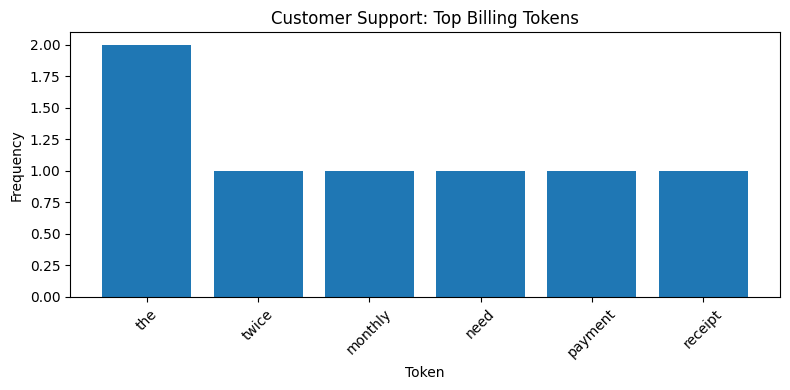

In [8]:
bigrams_list: list[tuple[str, str]] = []
for doc in corpus:
    tokens = tokenize(doc["text"])
    for i in range(len(tokens) - 1):
        bigrams_list.append((tokens[i], tokens[i + 1]))

bigram_df: pl.DataFrame = pl.DataFrame(
    {"bigram": [f"{a} {b}" for a, b in bigrams_list]}
)
bigram_freq_df: pl.DataFrame = (
    bigram_df.group_by("bigram").len().sort("len", descending=True)
)

print("Top bigrams:")
print(bigram_freq_df.head(15))

billing_df = category_freq_df.filter(pl.col("category") == "billing").head(6)
plt.figure(figsize=(8, 4))
plt.bar(billing_df["token"], billing_df["len"])
ax = plt.gca()
ax.tick_params(axis="x", labelrotation=45)
plt.title("Customer Support: Top Billing Tokens")
plt.xlabel("Token")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

## Reflection: Custom Application

### Describe your custom application (how did you change the text, the code)
I changed the corpus to customer support tickets across four categories: billing, technical, account access, and shipping. In the code, I kept the same code structure for (tokenization, frequency, co-occurrence, and bigrams) and updated the code to support terms: refund, error, password, and delivery.

### What is interesting about your custom application
This is interesting because it maps directly to a realistic helpdesk problem. Even with a small corpus, category language begins to emerge. 

### What insights did you gain
The bigrams that emerged here are good for support triage (for example, refund near duplicate/payment/card; error near server/timeout; password near forgot/sign in; delivery near date/order). 